# NEXTBUY: Exploratory Data Analysis (EDA)

## Part 2: Dataset Overview & Analysis

This notebook explores the data to understand patterns and distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import seaborn as sns
except ImportError:
    sns = None
    print("Note: seaborn not available, using matplotlib only")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Load Data

In [ ]:
DATA_PATH = Path("datasets/")
aisles = pd.read_csv(DATA_PATH / "aisles.csv")
departments = pd.read_csv(DATA_PATH / "departments.csv")
products = pd.read_csv(DATA_PATH / "products.csv")
orders = pd.read_csv(DATA_PATH / "orders.csv")
order_products = pd.read_csv(DATA_PATH / "order_products.csv")

In [ ]:
products_merged = products.merge(aisles, on="aisle_id").merge(departments, on="department_id")
order_products_merged = order_products.merge(products_merged, on="product_id")
full_data = order_products_merged.merge(orders, on="order_id")
full_data["days_since_prior_order"] = full_data["days_since_prior_order"].fillna(-1)
print(f"Full dataset shape: {full_data.shape}")

Full dataset shape: (13692437, 15)


## 1. Dataset Statistics

In [4]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nTotal rows: {full_data.shape[0]:,}")
print(f"Total columns: {full_data.shape[1]}")
print(f"\nMemory usage: {full_data.memory_usage(deep=True).sum() / 1e9:.2f} GB")

DATASET OVERVIEW

Total rows: 13,692,437
Total columns: 15

Memory usage: 3.98 GB


In [5]:
print("\n--- Unique Counts ---")
print(f"Unique users: {full_data['user_id'].nunique():,}")
print(f"Unique orders: {full_data['order_id'].nunique():,}")
print(f"Unique products: {full_data['product_id'].nunique():,}")
print(f"Unique aisles: {full_data['aisle_id'].nunique()}")
print(f"Unique departments: {full_data['department_id'].nunique()}")


--- Unique Counts ---
Unique users: 197,362
Unique orders: 1,357,539
Unique products: 49,067
Unique aisles: 134
Unique departments: 21


In [6]:
print("\n--- Numerical Statistics ---")
display(full_data.describe())


--- Numerical Statistics ---


,order_id,product_id,add_to_cart_order,reordered,aisle_id,department_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,1.369244e+07,1.369244e+07,1.369199e+07,1.369199e+07,1.369244e+07,1.369244e+07,1.369208e+07,1.369219e+07,1.369223e+07,1.369224e+07,1.281347e+07,13692437.0
mean,1.885226e+06,2.557284e+04,8.347785e+00,5.895890e-01,7.120799e+01,9.918454e+00,1.029534e+05,1.714602e+01,2.741731e+00,1.342386e+01,1.110300e+01,-1.0
std,9.644515e+05,1.409539e+04,7.125893e+00,4.919083e-01,3.820456e+01,6.280598e+00,5.945909e+04,1.753701e+01,2.089840e+00,4.246472e+00,8.781564e+00,0.0
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.0
25%,8.168250e+05,1.352400e+04,3.000000e+00,0.000000e+00,3.100000e+01,4.000000e+00,5.144700e+04,5.000000e+00,1.000000e+00,1.000000e+01,5.000000e+00,-1.0
50%,2.278485e+06,2.524600e+04,6.000000e+00,1.000000e+00,8.300000e+01,9.000000e+00,1.026280e+05,1.100000e+01,3.000000e+00,1.300000e+01,8.000000e+00,-1.0
75%,2.639194e+06,3.792300e+04,1.100000e+01,1.000000e+00,1.070000e+02,1.600000e+01,1.544060e+05,2.400000e+01,5.000000e+00,1.600000e+01,1.500000e+01,-1.0
max,2.999999e+06,4.968800e+04,1.270000e+02,1.000000e+00,1.340000e+02,2.100000e+01,2.062090e+05,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+01,-1.0


## 2. Order Timing Analysis

Orders with valid timing: 1,147,768 out of 1,444,444


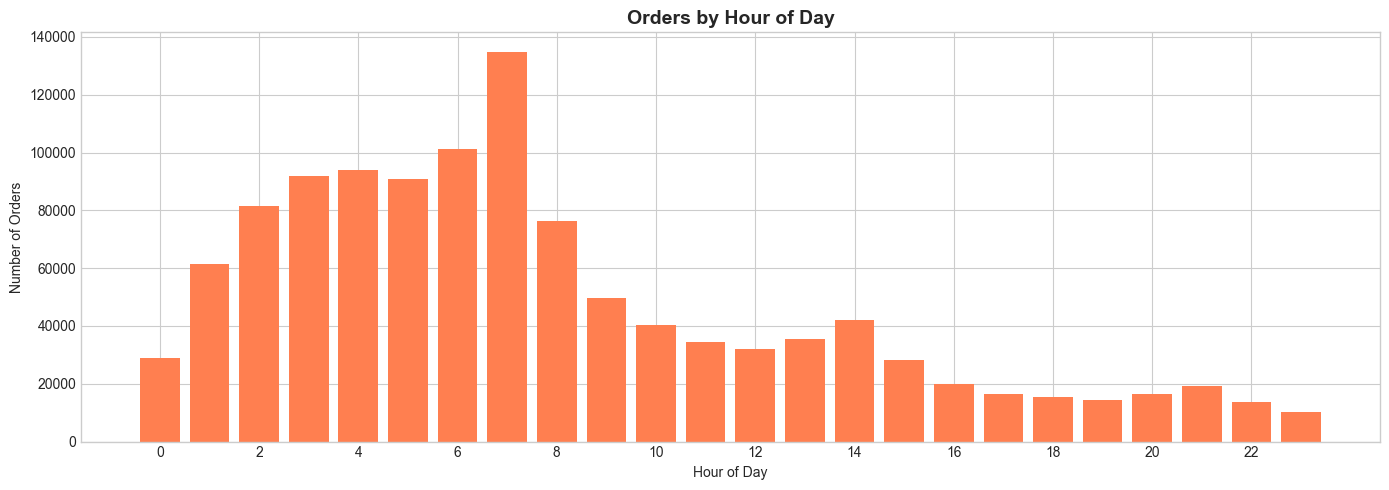

Peak hour: 7.0:00 with 134,830 orders


In [ ]:
orders_clean = orders.dropna(subset=['order_hour_of_day'])
orders_clean = orders_clean[orders_clean['order_hour_of_day'] <= 23]
print(f"Orders with valid timing: {len(orders_clean):,} out of {len(orders):,}")
hour_counts = orders_clean['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(hour_counts.index.astype(int), hour_counts.values, color='coral')
plt.title('Orders by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

print(f"Peak hour: {hour_counts.idxmax()}:00 with {hour_counts.max():,} orders")

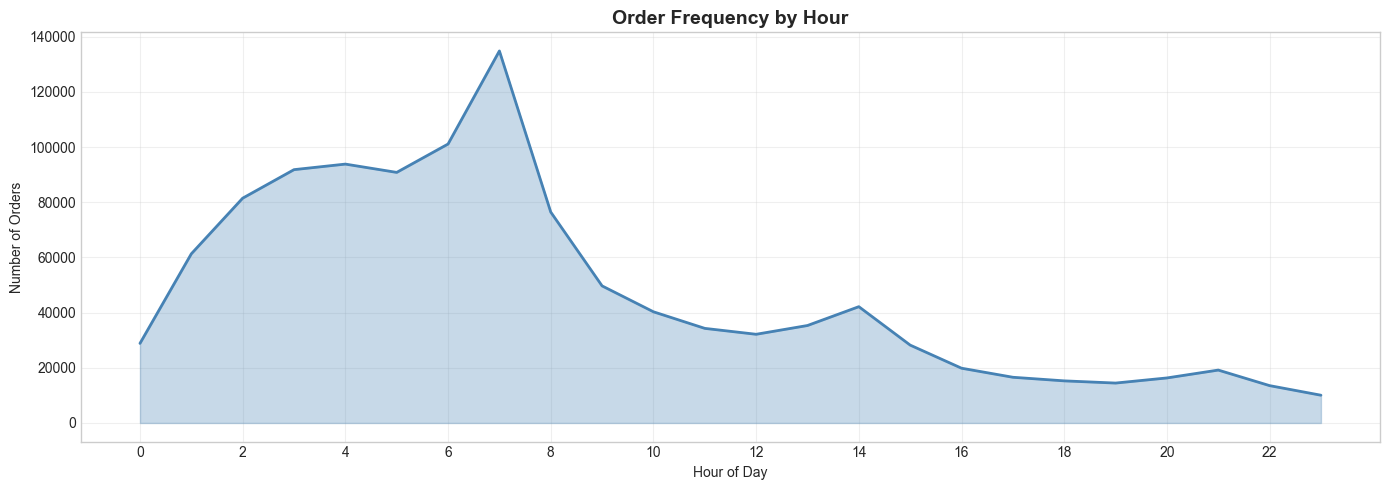

Insight: Peak ordering times are around 10am-4pm.


In [ ]:
order_heatmap = orders_clean.groupby(['order_hour_of_day']).size()

plt.figure(figsize=(14, 5))
plt.fill_between(order_heatmap.index.astype(int), order_heatmap.values, alpha=0.3, color='steelblue')
plt.plot(order_heatmap.index.astype(int), order_heatmap.values, color='steelblue', linewidth=2)
plt.title('Order Frequency by Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight: Peak ordering times are around 10am-4pm.")

## 3. Product Analysis - Bestsellers

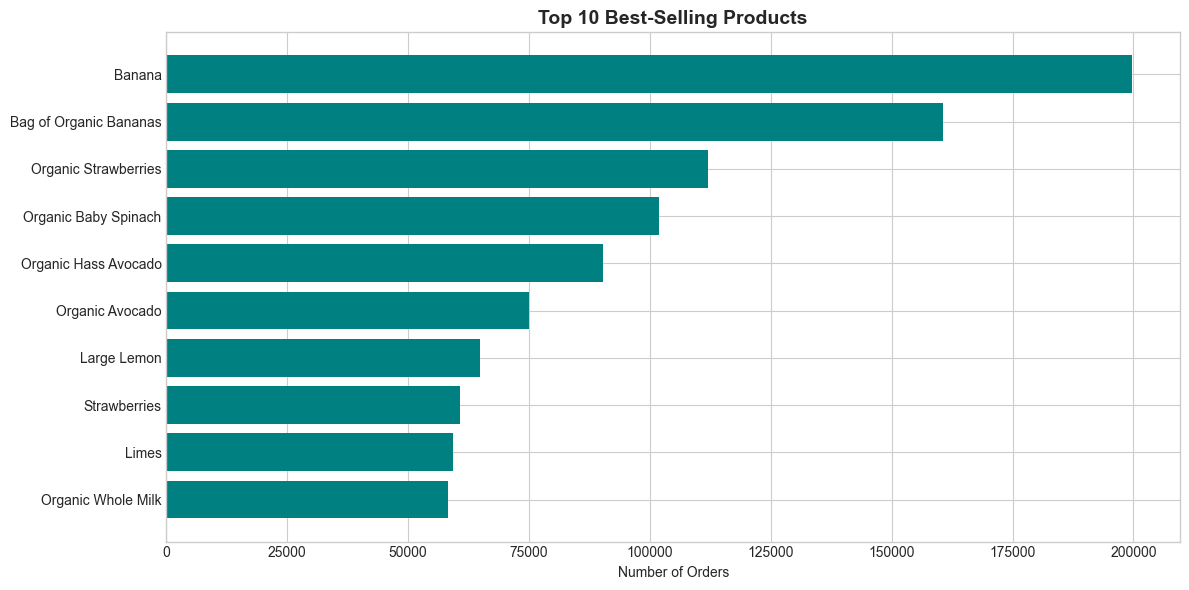


Top 10 Products:
1. Banana: 199,654
2. Bag of Organic Bananas: 160,615
3. Organic Strawberries: 111,975
4. Organic Baby Spinach: 101,915
5. Organic Hass Avocado: 90,372
6. Organic Avocado: 74,961
7. Large Lemon: 64,862
8. Strawberries: 60,763
9. Limes: 59,301
10. Organic Whole Milk: 58,210


In [ ]:
top_products = full_data['product_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(10), top_products.values[::-1], color='teal')
plt.yticks(range(10), top_products.index[::-1])
plt.title('Top 10 Best-Selling Products', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

print("\nTop 10 Products:")
for i, (product, count) in enumerate(top_products.items(), 1):
    print(f"{i}. {product}: {count:,}")

## 4. Category Analysis

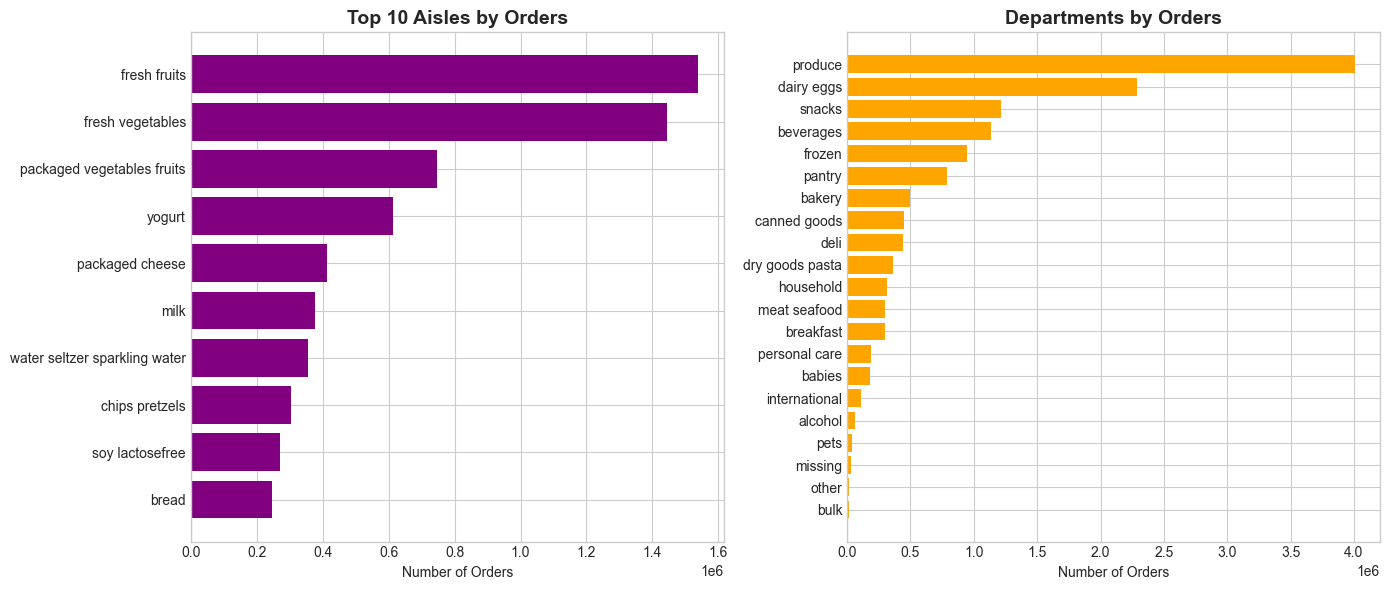

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_aisles = full_data['aisle'].value_counts().head(10)
axes[0].barh(range(10), top_aisles.values[::-1], color='purple')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top_aisles.index[::-1])
axes[0].set_title('Top 10 Aisles by Orders', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Orders')

top_depts = full_data['department'].value_counts()
axes[1].barh(range(len(top_depts)), top_depts.values[::-1], color='orange')
axes[1].set_yticks(range(len(top_depts)))
axes[1].set_yticklabels(top_depts.index[::-1])
axes[1].set_title('Departments by Orders', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Orders')

plt.tight_layout()
plt.show()

## 5. Reorder Analysis

Overall Reorder Rate: 58.96%


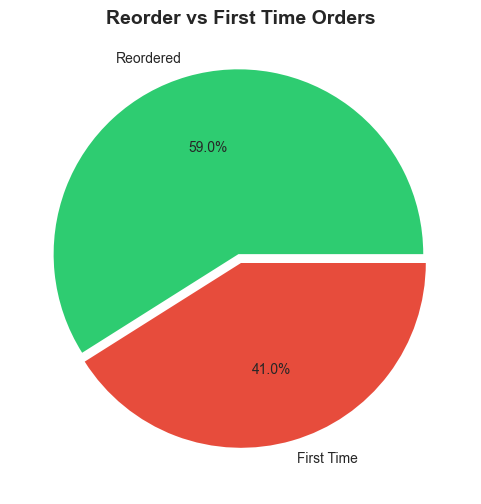

In [11]:
reorder_rate = full_data['reordered'].mean() * 100
print(f"Overall Reorder Rate: {reorder_rate:.2f}%")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.pie([reorder_rate, 100-reorder_rate], 
       labels=['Reordered', 'First Time'], 
       autopct='%1.1f%%',
       colors=['#2ecc71', '#e74c3c'],
       explode=(0.05, 0))
ax.set_title('Reorder vs First Time Orders', fontsize=14, fontweight='bold')
plt.show()

## 6. Cart Size Analysis

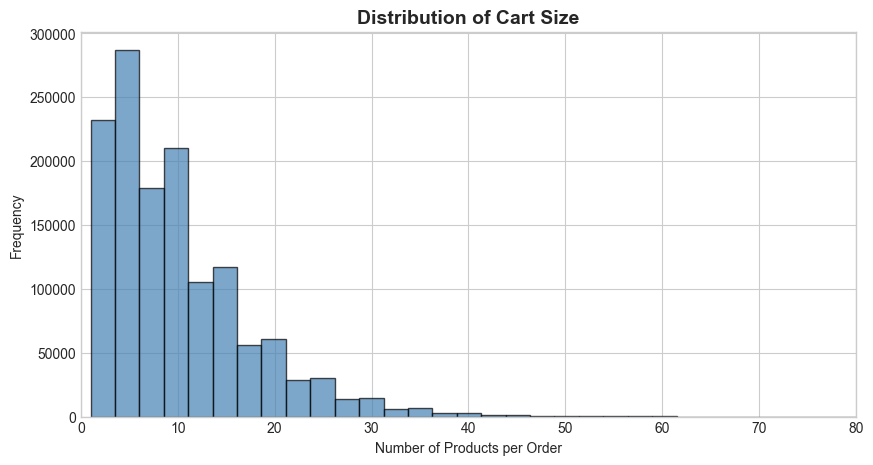


Cart Size Statistics:
Mean: 10.09 products
Median: 8 products
Max: 127 products


In [ ]:
cart_size = full_data.groupby('order_id').size()

plt.figure(figsize=(10, 5))
plt.hist(cart_size, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Cart Size', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products per Order')
plt.ylabel('Frequency')
plt.xlim(0, 80)
plt.show()

print(f"\nCart Size Statistics:")
print(f"Mean: {cart_size.mean():.2f} products")
print(f"Median: {cart_size.median():.0f} products")
print(f"Max: {cart_size.max()} products")

## Summary

In [13]:
print("="*60)
print("EDA SUMMARY")
print("="*60)
print(f"""
Key Findings:
- {full_data['user_id'].nunique():,} unique users
- {full_data['order_id'].nunique():,} unique orders  
- {full_data['product_id'].nunique():,} unique products
- {reorder_rate:.1f}% reorder rate
- Average cart size: {cart_size.mean():.1f} products
- Peak ordering: 10am - 4pm
- Best selling aisle: {top_aisles.index[0]}
- Best selling department: {top_depts.index[0]}
""")

EDA SUMMARY

Key Findings:
- 197,362 unique users
- 1,357,539 unique orders  
- 49,067 unique products
- 59.0% reorder rate
- Average cart size: 10.1 products
- Peak ordering: 10am - 4pm
- Best selling aisle: fresh fruits
- Best selling department: produce

